# Lab 9.2: CNN Training with Image Augmentation

**Student Name:** Yousaf Tahir  
**Registration Number:** 22JZELE0479  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Nowshera Campus  


## Learning Objectives
- Import required TensorFlow/Keras and evaluation libraries.
- Define image dataset paths for training, validation, and testing.
- Build and compile a CNN model for image classification.
- Use ImageDataGenerator for rescaling and augmentation.
- Train the model and evaluate it using plots, confusion matrix, and classification report.

## Section 1: Library Import and Dataset Paths
This section imports Keras tools, plotting libraries, and evaluation metrics, then defines paths for train, validation, and test image folders.


In [1]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [2]:
checkpoints = r'D:\Machine Learning\ML Lab\Lab 9\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [3]:
train_dir = r'D:\Machine Learning\ML Lab\Lab 9\Computer vision\sectionB\train'
validation_dir = r'D:\Machine Learning\ML Lab\Lab 9\Computer vision\sectionB\validation'
test_dir = r'D:\Machine Learning\ML Lab\Lab 9\Computer vision\sectionB\test'

## Section 2: CNN Model Architecture
The following cells create and summarize the convolutional neural network used for classification.


In [4]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4, activation='sigmoid'))

c:\Users\Yousaf Tahir\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

In [7]:
train_datagen = ImageDataGenerator(
                                    rescale=1./255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
                                                    train_dir,
                                                    target_size=(256, 256),
                                                    batch_size=32,
                                                    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory(
                                                        validation_dir,
                                                        target_size=(256, 256),
                                                        batch_size=32,
                                                        class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


## Section 3: Data Generators, Augmentation, and Training
This section prepares image generators, applies rescaling/augmentation, sets checkpoints, and trains the CNN model.


In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [9]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [10]:
model_history = model.fit(train_generator,
                         validation_data =validation_generator,
                         steps_per_epoch=train_generator.n//train_generator.batch_size,
                         validation_steps = validation_generator.n//validation_generator.batch_size,
                         epochs = 3,
                         callbacks = callbacks)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5312 - loss: 1.0830
Epoch 1: val_loss improved from None to 0.80334, saving model to D:\Machine Learning\ML Lab\Lab 9\\E1-cp-0001-loss0.80.h5



Epoch 1: finished saving model to D:\Machine Learning\ML Lab\Lab 9\\E1-cp-0001-loss0.80.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.5312 - loss: 1.0830 - val_accuracy: 0.6027 - val_loss: 0.8033
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7425 - loss: 0.6001
Epoch 2: val_loss improved from 0.80334 to 0.46856, saving model to D:\Machine Learning\ML Lab\Lab 9\\E1-cp-0002-loss0.47.h5



Epoch 2: finished saving model to D:\Machine Learning\ML Lab\Lab 9\\E1-cp-0002-loss0.47.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.7425 - loss: 0.6001 - val_accuracy: 0.7768 - val_loss: 0.4686
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7975 - loss: 0.4469
Epoch 3: val_loss improved from 0.46856 to 0.39035, saving model to D:\Machine Learning\ML Lab\Lab 9\\E1-cp-0003-loss0.39.h5



Epoch 3: finished saving model to D:\Machine Learning\ML Lab\Lab 9\\E1-cp-0003-loss0.39.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.7975 - loss: 0.4469 - val_accuracy: 0.7946 - val_loss: 0.3903


In [11]:
model_history.history

{'accuracy': [0.53125, 0.7425000071525574, 0.7975000143051147],
 'loss': [1.0829612016677856, 0.6001245379447937, 0.4468784034252167],
 'val_accuracy': [0.6026785969734192, 0.7767857313156128, 0.7946428656578064],
 'val_loss': [0.8033379316329956, 0.4685552418231964, 0.39034730195999146]}

## Section 4: Model Evaluation
The final cells evaluate model performance using plots, predictions, confusion matrix, and classification report.


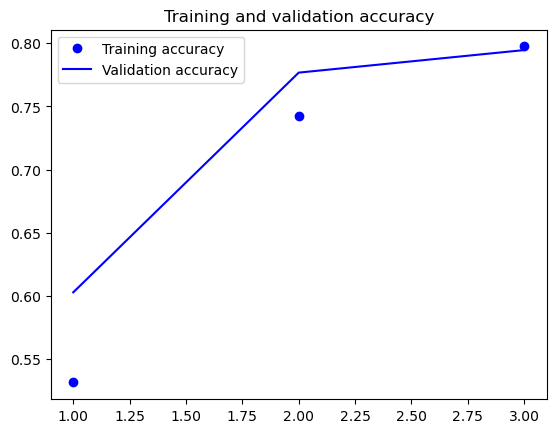

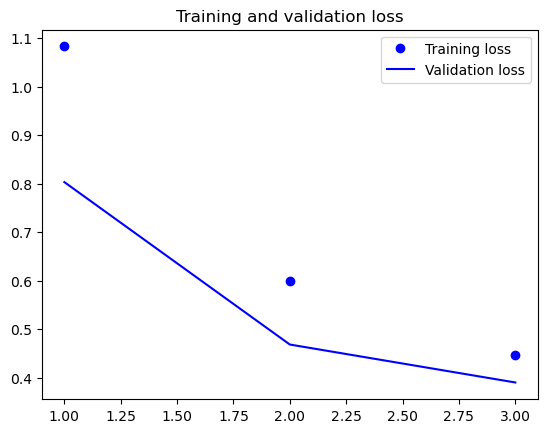

In [12]:
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.savefig(r'D:\Machine Learning\ML Lab\Lab 9\model_Accuracy.png')

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.savefig(r'D:\Machine Learning\ML Lab\Lab 9\model_Loss.png')

plt.show()

Found 200 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step


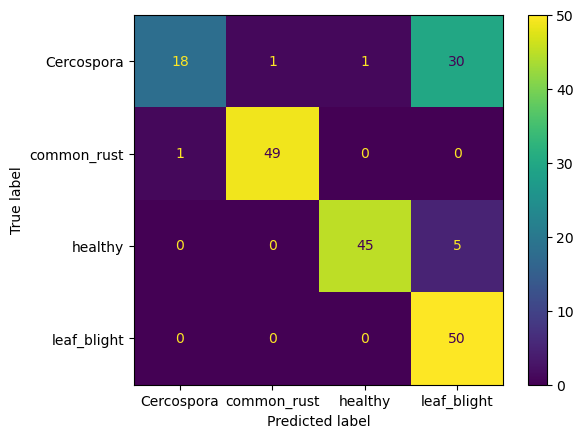

In [13]:
model = load_model(r'D:\Machine Learning\ML Lab\Lab 9\\E1-cp-0003-loss0.39.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\confusion_matrics.jpg')

In [14]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.95      0.36      0.52        50
 common_rust       0.98      0.98      0.98        50
     healthy       0.98      0.90      0.94        50
 leaf_blight       0.59      1.00      0.74        50

    accuracy                           0.81       200
   macro avg       0.87      0.81      0.79       200
weighted avg       0.87      0.81      0.79       200



## Final Conclusion
In this lab, a CNN model was trained using image augmentation and evaluated on corn leaf image classes. This workflow connects dataset preparation, augmentation, model training, and classification evaluation.

